Names - ID:
- Angie B Granada - F11301102
- Clarisa Villate - F11301116

## Decission Tree
#### Week 6-7 Assigment

### 1. Imports


In [12]:
import pandas as pd               #Reads and  datsets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2.Loading Data

In [23]:
# Data Loading
df = pd.read_csv("steel_plates_faults.csv")
df.head()


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,108,1687,...,-0.2913,0.5822,76,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,-0.1756,0.2984,84,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,-0.1228,0.2150,99,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,126,1353,...,-0.1568,0.5212,99,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,-0.1992,1.0000,37,1,0,0,0,0,0,0


### 3. Check the Dataset
Checking the shape of the dataset and verifying there are no missing values.

In [14]:
print("Shape del dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Shape del dataset: (1941, 34)

Valores nulos por columna:
X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Minimum_of_Luminosity    0
Pastry                   0
Z_Scratch                0
K_Scratch                0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64


cmt:
- Our dataset have 1941 rows, 34 columns
- We checked if we have null values with 'df.isnull().sum()' --> We obtained that we have cero null values

### 4.Preprocessing
The 7 fault types are stored as one-hot encoded columns (each row has a `1` in exactly one column).
We reverse this into a single `Fault_Type` column, which is required for the Decision Tree classifier.



In [24]:
target_cols = [ "Pastry", "Z_Scratch", "K_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"
]
print(target_cols)


df["Fault_Type"] = df[target_cols].idxmax(axis=1)
df[["Fault_Type"] + target_cols].head(10)

['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']


,Fault_Type,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,Pastry,1,0,0,0,0,0,0
1,Pastry,1,0,0,0,0,0,0
2,Pastry,1,0,0,0,0,0,0
3,Pastry,1,0,0,0,0,0,0
4,Pastry,1,0,0,0,0,0,0
5,Pastry,1,0,0,0,0,0,0
6,Pastry,1,0,0,0,0,0,0
7,Pastry,1,0,0,0,0,0,0
8,Pastry,1,0,0,0,0,0,0
9,Pastry,1,0,0,0,0,0,0


### 5. Exploratory Data ANalysis (EDA)
Before modeling, we will explore the data to find if the Fault type is balanced or inbalanced. Also do a correlation to find if some feautures arre redundant or not.

Class Distribution:
Fault_Type
Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


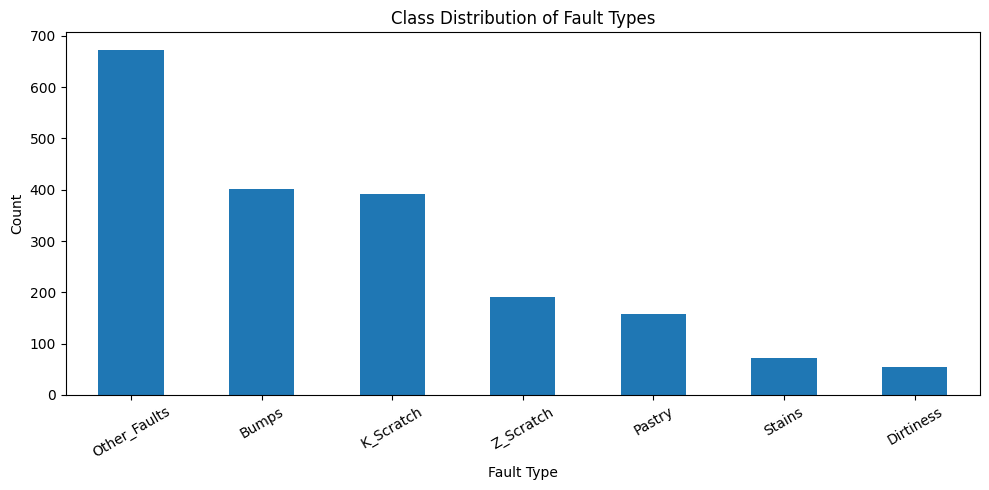


Defect dimensions by Fault Type:
              Defect_Width  Defect_Length
Fault_Type                               
Bumps                17.77          19.18
Dirtiness            11.24          56.71
K_Scratch           148.47         136.44
Other_Faults         28.62          34.29
Pastry               11.07          57.09
Stains                7.07           4.83
Z_Scratch            18.73          41.42


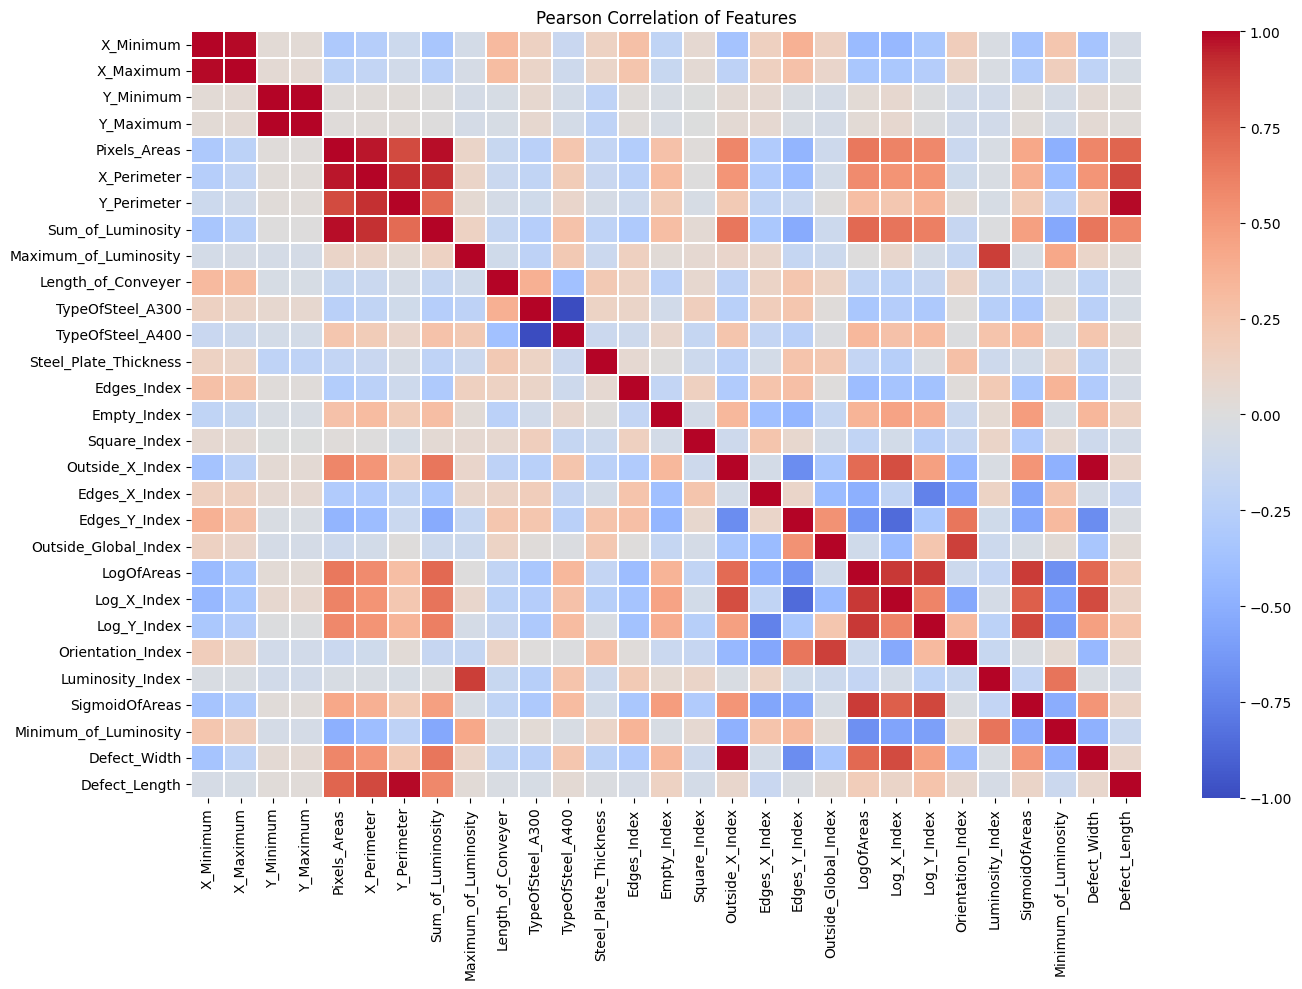


Defect Density by Fault Type:
              Defect_Density
Fault_Type                  
Bumps                 0.6320
Dirtiness             0.5959
K_Scratch             0.5430
Other_Faults          0.5767
Pastry                0.6711
Stains                0.5930
Z_Scratch             0.5318


In [ ]:

#  Exploratory Data Analysis (EDA)
#Class Distribution
print("Class Distribution:")
print(df["Fault_Type"].value_counts())

plt.figure(figsize=(10, 5))
df["Fault_Type"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Fault Types")
plt.xlabel("Fault Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Calculate the physical dimensions of the defect bounding box.
df["Defect_Width"]  = df["X_Maximum"] - df["X_Minimum"]
df["Defect_Length"] = df["Y_Maximum"] - df["Y_Minimum"]

print("\nDefect dimensions by Fault Type:")
print(df[["Fault_Type", "Defect_Width", "Defect_Length"]].groupby("Fault_Type").mean().round(2))

# Correlation Analysis
feature_df = df.drop(columns=target_cols + ["Fault_Type"])

plt.figure(figsize=(14, 10))
sns.heatmap(
    feature_df.astype(float).corr(),
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.1
)
plt.title("Pearson Correlation of Features")
plt.tight_layout()
plt.show()

#  Calculate Defect Density (Pixels_Areas / Bounding Box Area)
# Hint: Add + 1e-5 to the denominator to prevent Division by Zero errors!
df["Bounding_Box_Area"] = df["Defect_Width"] * df["Defect_Length"]
df["Defect_Density"]    = df["Pixels_Areas"] / (df["Bounding_Box_Area"] + 1e-5)

print("\nDefect Density by Fault Type:")
print(df[["Fault_Type", "Defect_Density"]].groupby("Fault_Type").mean().round(4))



cmt:
- The dataset is unbalanced --> we used `class_weight="balanced"` to compensate.

- The physical dimensions distinguish defects well --> `Defect_Width` and `Defect_Length` are important features for the tree.

- The density is similar across all elements --> this feature alone isn't sufficient, but combined with the others, it can provides valuable information.

### 6. Feature Engineering


In [28]:
# Feature Engineering (Adding Physical Context)
df["Aspect_Ratio"] = df["Defect_Width"] / (df["Defect_Length"] + 1e-5)

# We verify tha the 5 new features are ok
new_features = ["Defect_Width", "Defect_Length", "Bounding_Box_Area", "Defect_Density", "Aspect_Ratio"]
print("New features:")
print(df[["Fault_Type"] + new_features].groupby("Fault_Type").mean().round(3))


New features:
              Defect_Width  Defect_Length  Bounding_Box_Area  Defect_Density  \
Fault_Type                                                                     
Bumps               17.774         19.184            480.266           0.632   
Dirtiness           11.236         56.709            650.745           0.596   
K_Scratch          148.468        136.442          23362.061           0.543   
Other_Faults        28.624         34.294           1281.328           0.577   
Pastry              11.070         57.095            920.354           0.671   
Stains               7.069          4.833             37.625           0.593   
Z_Scratch           18.726         41.416           1222.768           0.532   

              Aspect_Ratio  
Fault_Type                  
Bumps                1.046  
Dirtiness            0.697  
K_Scratch            1.850  
Other_Faults         2.020  
Pastry               0.367  
Stains               1.515  
Z_Scratch            0.816  


cmt:

- What does Aspect_Ratio do?

    - If width > length → ratio > 1 → default width is wider than height (horizontal)

    - If width < length → ratio < 1 → default height is taller than width (vertical, like a line)

    - If width ≈ length → ratio ≈ 1 → default square (like Bumps or Stains)


cmt results:
- Pastry = 0.367 → very thin and vertical (Width much less than Length)
- K_Scratch = 1.850 → wider than tall
- Bumps = 1.046 → almost perfectly square
- Stains = 1.515 → slightly wider than tall

(The tree will be able to use this to distinguish defects)

### 7.Define Features (X) and Target (y)
Separating the input features from the target label.
- `X` → all sensor measurements + engineered features
- `y` → the fault type (what the model must predict)

In [18]:
# Define Features (X) and Target (y)
X = df.drop(columns=target_cols + ["Fault_Type"])
y = df["Fault_Type"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nFeatures que usará el modelo:")
print(X.columns.tolist())

Shape de X: (1941, 32)
Shape de y: (1941,)

Features que usará el modelo:
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Minimum_of_Luminosity', 'Defect_Width', 'Defect_Length', 'Bounding_Box_Area', 'Defect_Density', 'Aspect_Ratio']


### 8. Train-Test Split
Splitting the data into 80% training and 20% test set.

In [30]:

# Train-Test Split & Model Setup

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Size/shape of the Train set:", X_train.shape)
print("Size/shape of the Test set::", X_test.shape)

Size/shape of the Train set: (1552, 32)
Size/shape of the Test set:: (389, 32)


### 9. Cross Validation
Using K-Fold Cross Validation (k=5) to find the optimal `max_depth` parameter.

This prevents **overfitting**. If the tree grows too deep, it memorizes training data instead of learning general rules.

In [20]:
# Cross Validation to find best max_depth
from sklearn.model_selection import KFold
from sklearn import tree

cv = KFold(n_splits=5)
accuracies = list()
max_attributes = 15
depth_range = range(1, max_attributes + 1)

train_df = X_train.copy()
train_df["Fault_Type"] = y_train.values

for depth in depth_range:
    fold_accuracy = []
    tree_model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    for train_fold, valid_fold in cv.split(train_df):
        f_train = train_df.iloc[train_fold]
        f_valid  = train_df.iloc[valid_fold]

        model = tree_model.fit(
            X = f_train.drop(["Fault_Type"], axis=1),
            y = f_train["Fault_Type"]
        )
        valid_acc = model.score(
            X = f_valid.drop(["Fault_Type"], axis=1),
            y = f_valid["Fault_Type"]
        )
        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy) / len(fold_accuracy)
    accuracies.append(avg)

results = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
print(results.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.101182
         2          0.253219
         3          0.393660
         4          0.465854
         5          0.543191
         6          0.610802
         7          0.659108
         8          0.670080
         9          0.679747
        10          0.677164
        11          0.675882
        12          0.682328
        13          0.682336
        14          0.677820
        15          0.679753


### 10. Initialization of DT & Model Training
Since we found that the optimal max_dept for the tree is 12, thanks to the cross validation we will start training the DT.


In [ ]:
# Initialize Decision Tree
# max_depth=12 encontrado por Cross Validation — previene overfitting
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

### 11. Evaluation & Quality Control Report
Evaluating the model on the test set (unseen plates).
- **Accuracy**: overall percentage of correct predictions
- **Precision**: of all plates predicted as fault X, how many actually were X?
- **Recall**: of all actual fault X plates, how many did we correctly detect?
- **F1-score**: harmonic mean of precision and recall
- **Confusion Matrix**: shows exactly which fault types are being confused with each other



Model Accuracy on Unseen Plates: 73.26%

Detailed Quality Control Report:
              precision    recall  f1-score   support

       Bumps       0.56      0.69      0.62        72
   Dirtiness       0.50      0.75      0.60         8
   K_Scratch       0.91      0.93      0.92        83
Other_Faults       0.74      0.63      0.68       143
      Pastry       0.48      0.41      0.44        29
      Stains       0.86      0.92      0.89        13
   Z_Scratch       0.93      0.93      0.93        41

    accuracy                           0.73       389
   macro avg       0.71      0.75      0.72       389
weighted avg       0.74      0.73      0.73       389



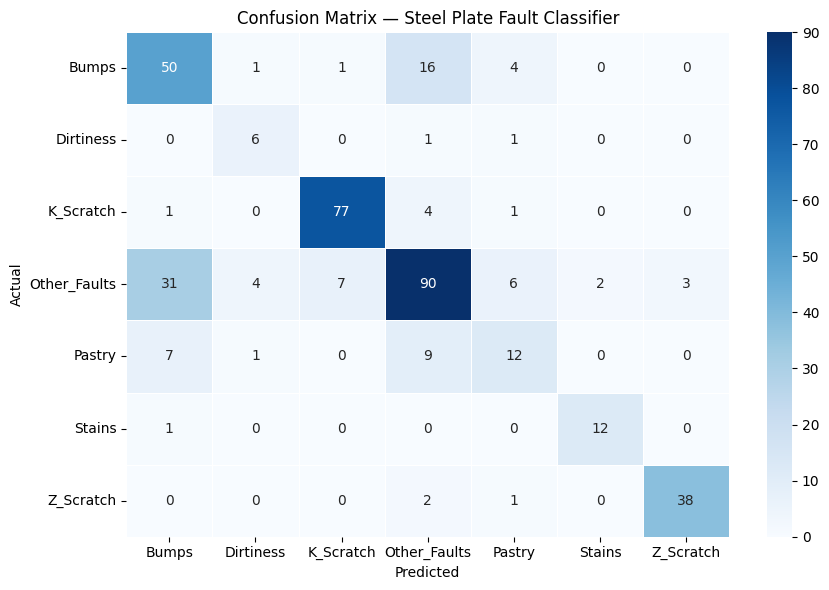

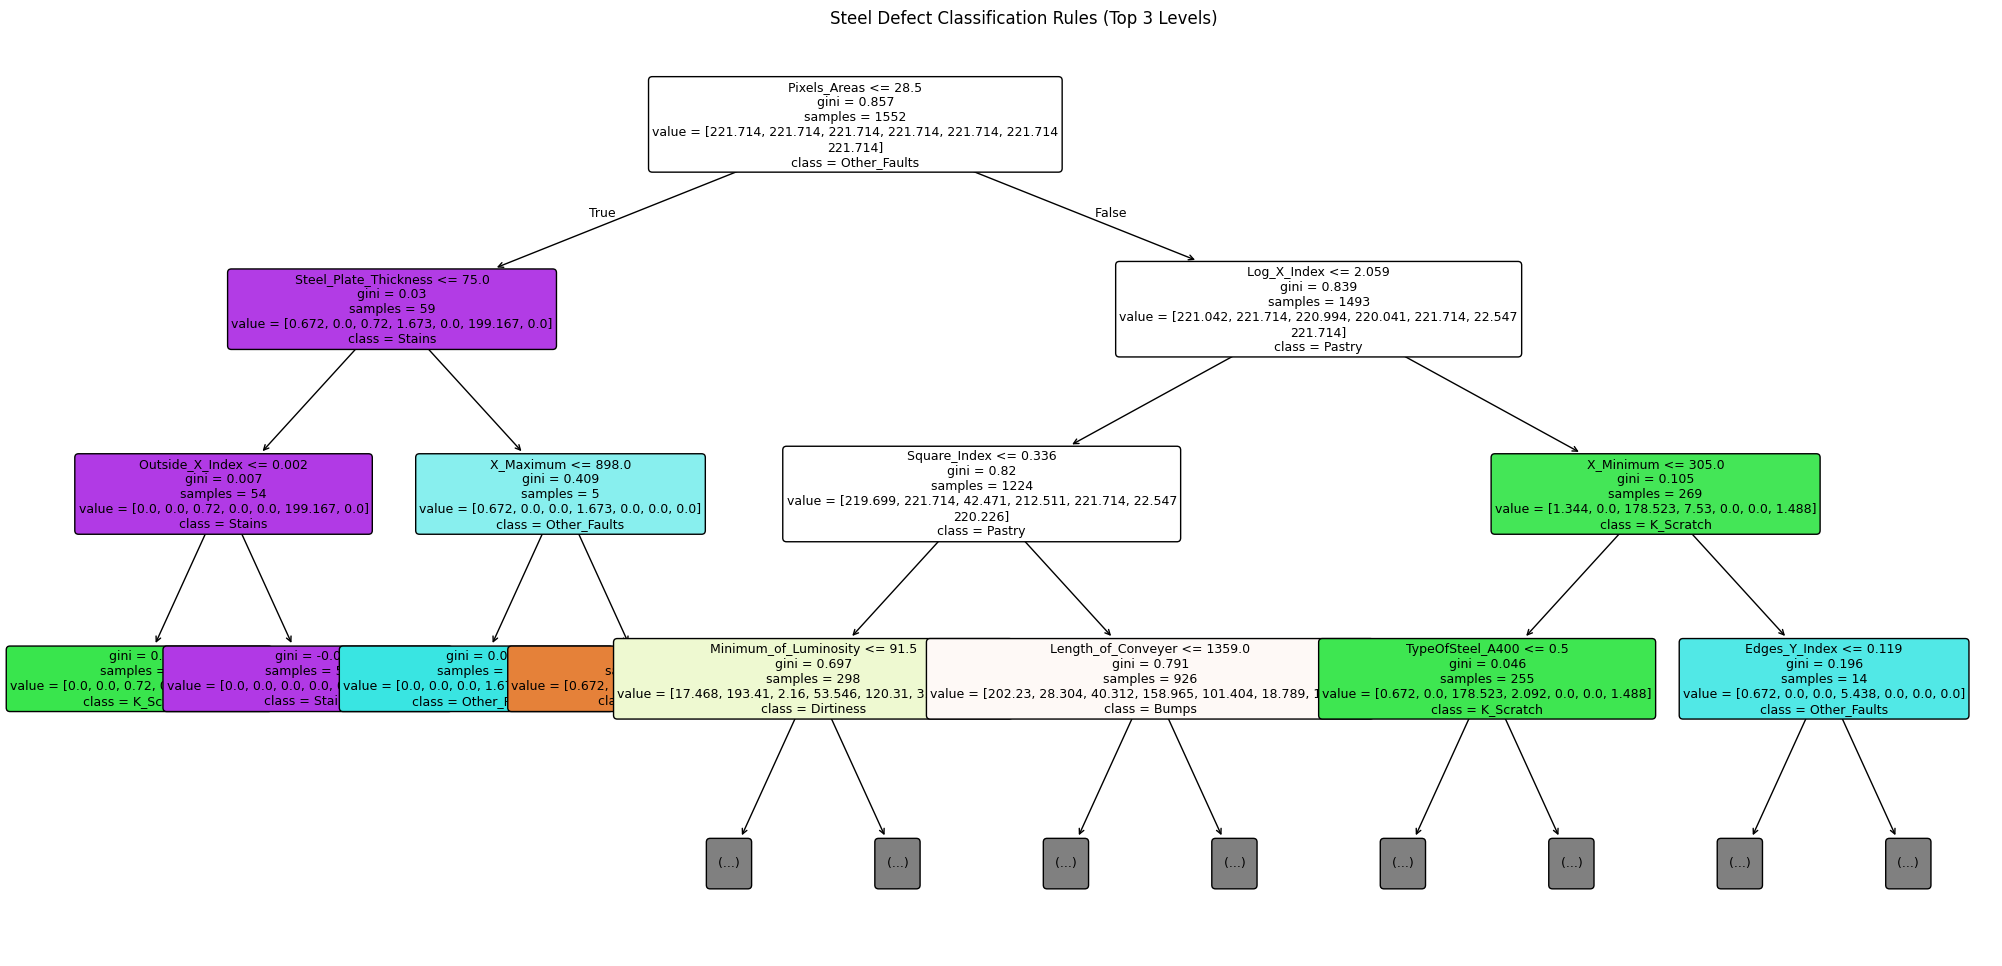

In [32]:

#  Evaluation & QC Report
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Unseen Plates: {accuracy * 100:.2f}%")

print("\nDetailed Quality Control Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

plt.figure(figsize=(9, 6))
sns.heatmap( cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5, xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_
)
plt.title("Confusion Matrix — Steel Plate Fault Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Visualizing the "Business Rules"
plt.figure(figsize=(25, 12))
plot_tree( dt_model, feature_names=X.columns, class_names=[str(c) for c in dt_model.classes_], 
    filled=True, rounded=True,
    max_depth=3, # Only plotting top 3 levels for readability
    fontsize=9
)
plt.title("Steel Defect Classification Rules (Top 3 Levels)")
plt.show()